# Introduction to Multilayer Perceptrons 

In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import torch.nn as nn

plt.style.use('fivethirtyeight')

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: {}".format(device))

Using device: cpu


## Introduction to Pytorch with Simple Linear Regression 

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Use GPU if available, else fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Generate synthetic dataset and move to device
torch.manual_seed(1)
X = torch.linspace(0, 10, 100).unsqueeze(1).to(device)
y = (2 * X + 1 + torch.randn(X.size(), device=device) * 2).to(device) # .to(device) is need utilize gpu

# Define model using nn.Sequential for a linear layer, move to device
model = nn.Linear(1, 1).to(device) # .to(device) is need utilize gpu nn.Sequential(

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Record loss
losses = []

# Training loop
epochs = 10
for epoch in range(epochs):  # Loop through the dataset multiple times (each loop is one epoch)

    # Reset gradients from the previous step to zero before computing new ones
    optimizer.zero_grad()   
    
    # Forward pass: feed input data (X) through the model to get predictions
    # Note: this is where the batch is set; the number of datapoints that go through the forward pass
    outputs = model(X) 

     # Calculate the difference between predictions and true values (the loss)
    loss = criterion(outputs, y)  

    # Backward pass: compute gradients of the loss with respect to model parameters
    loss.backward()  

     # Update model parameters using gradients (gradient descent)
    optimizer.step() 

    # Store the current loss value for plotting/analysis later
    losses.append(loss.item())     
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')  # Print the loss to see progress over time

Epoch 1, Loss: 57.4812
Epoch 2, Loss: 9.1144
Epoch 3, Loss: 4.3173
Epoch 4, Loss: 3.8415
Epoch 5, Loss: 3.7942
Epoch 6, Loss: 3.7895
Epoch 7, Loss: 3.7890
Epoch 8, Loss: 3.7890
Epoch 9, Loss: 3.7889
Epoch 10, Loss: 3.7889


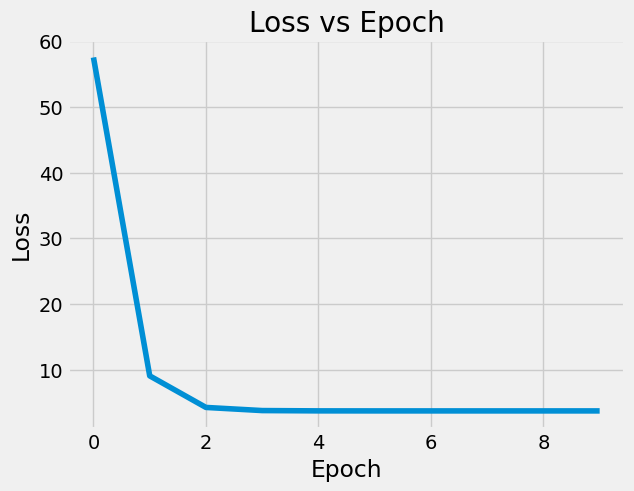

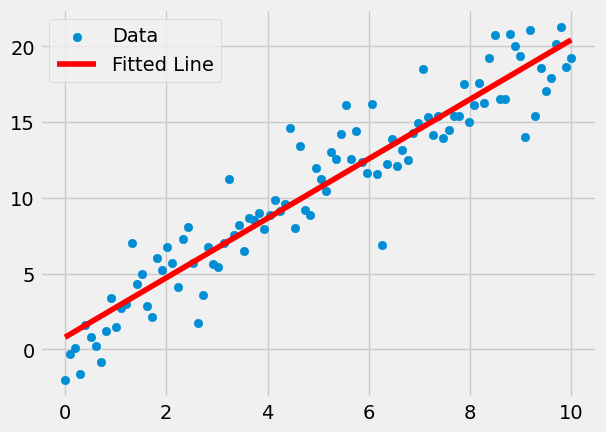

In [4]:
# Plot loss vs epoch
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()

# Plot the data and the regression line
predicted = model(X).detach().cpu()
plt.scatter(X.cpu().numpy(), y.cpu().numpy(), label="Data")
plt.plot(X.cpu().numpy(), predicted.numpy(), color='red', label="Fitted Line")
plt.legend()
plt.show()

## Multilayer Perceptrons 

Here are a few simple example Multi-Layer Perceptrons (MLPs) built using PyTorch's nn.Sequential that mirror what we say in lecture.  `nn.Sequetial` is a helpful tool in Pytorch that allows you to build sequential models.  We will use this to build MLPs in this 

In [5]:
# Multiple linear regression with 2 features
model = nn.Sequential(nn.Linear(2, 1))
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)

In [6]:
# Logistic Regression model with 2 input features and single output
model = nn.Sequential(
    nn.Linear(2, 1),  # linear layer: 2 input features to 1 output
    nn.Sigmoid()      # sigmoid activation for outputting probability
)

In [7]:
# 1 hidden layer with 2 nodes 
model1 = nn.Sequential(
    nn.Linear(2, 2),  # input layer (10 features) to hidden layer (20 units)
    nn.ReLU(),          # activation function
    nn.Linear(2, 1)    # output layer (single output)
)
model1

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)

## MLP Helper Functions

In [8]:
##########################################
# HELPER FUNCTIONS for data visualization
##########################################

In [9]:
def plot_loss_v_epochs(ax, losses, test_data=None, title="Loss v Epoch"):
    ax.plot(range(1, len(losses)+1), losses, marker='o', label='train loss')
    if test_data is not None:
        ax.plot(range(1, len(test_data)+1), test_data, marker='^', label='test loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Squared Error Loss')
    ax.legend()

def plot_model(ax, X, Y, model):
    # plot noisy data points
    ax.scatter(X.numpy(), Y.numpy(), label='Noisy data')
    X_plot = torch.linspace(-2, 3, 100).reshape(-1, 1)
    # plot model prediction
    ax.plot(X_plot.numpy(), model(X_plot).detach().numpy(), color='red', label='Fitted line')
    ax.set_title('Final model vs Noisy data')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()

def train_model(model,optimizer,loss_fn,train_loader,test_loader,train_size,test_size,epochs=3,verbose=False):
    # move model to device
    model.to(device) 
    
    # Training loop
    test_losses=[]
    train_losses=[]
    
    for epoch in range(epochs):
     #   epoch_loss = 0.0
        model.train()
        running_train_loss = 0.0
        # Epoch of Training Loop
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            y_pred = model(xb)
            loss = loss_fn(y_pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * xb.size(0)

        avg_train_loss = running_train_loss / train_size
        train_losses.append(avg_train_loss)
        
        # Evaluation After Each Epoch
        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():                  # We do not need to compute gradients when doing evaluation
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                y_pred = model(xb)
                loss = loss_fn(y_pred, yb)
                running_test_loss += loss.item() * xb.size(0)
        
        avg_test_loss = running_test_loss / test_size
        test_losses.append(avg_test_loss)

        if verbose:
            print(f'Epoch: {epoch+1} Train Loss: {avg_train_loss:.4f} Test Loss: {avg_test_loss:.4f}')
           # print('Epoch: {} Train Score: {} Test Score: {}'.format(epoch,avg_train_loss,avg_test_loss))
    return model, train_losses, test_losses

def train_mlp(layer_sizes, learning_rate, epochs, batch_size, verbose=False):
    '''
    trains MLP model with arbitrary number of layers and nodes per layer
    layer_sizes: list of ints, including input and output layer sizes
      e.g. [1, 10, 5, 1] means input layer 1 node, two hidden layers (10 and 5 nodes),
           output layer 1 node
    creates data visualizations of results 
    '''
    # pass train and test data into DataLoader 
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # dynamically create layers
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
        # add ReLU activation for all layers except last
        if i < len(layer_sizes) - 2:
            layers.append(nn.ReLU())
    
    # instantiate model as sequential container of layers
    model = nn.Sequential(*layers)
    
    # Optimizer 
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.99)
    
    # Loss function
    loss_fn = nn.MSELoss()
    
    # train model
    model, losses, test_losses = train_model(model, optimizer, loss_fn, train_loader, test_loader, train_size,test_size, epochs=epochs, verbose=verbose)
    
    # plot results
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_loss_v_epochs(ax[0], losses, test_data=test_losses, title="Loss v Epoch")
    plot_model(ax[1], X, Y, model)
    fig.suptitle('Layer sizes: {}'.format(layer_sizes))
    fig.tight_layout()

### Create Random Dataset

In [10]:
# Generate data with noise
torch.manual_seed(0)  # For reproducibility
num_samples = 200
X = 5 * torch.rand(num_samples, 1) - 2  # uniform random values in [-3, 3]
noise = 2*torch.randn(num_samples, 1)
Y = X**3 - 2 * X**2 + noise

# Create dataset
dataset = TensorDataset(X, Y)

# Split dataset into 80% train and 20% test
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

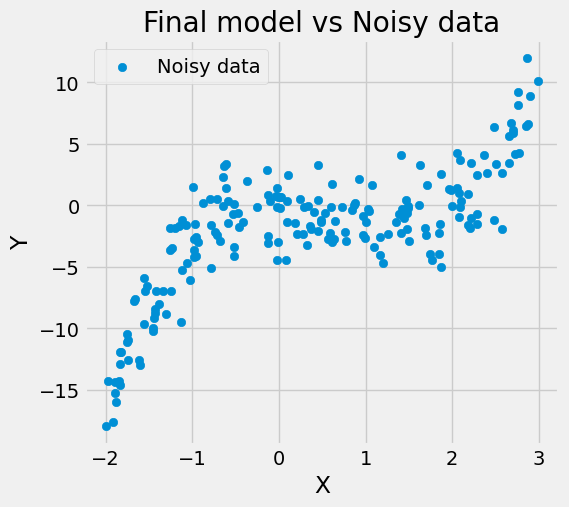

In [11]:
# Plot the final model vs noisy data points
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X.numpy(), Y.numpy(), label='Noisy data')
#plt.plot(X.numpy(), (X * w + b).detach().numpy(), color='red', label='Fitted line')
plt.title('Final model vs Noisy data')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

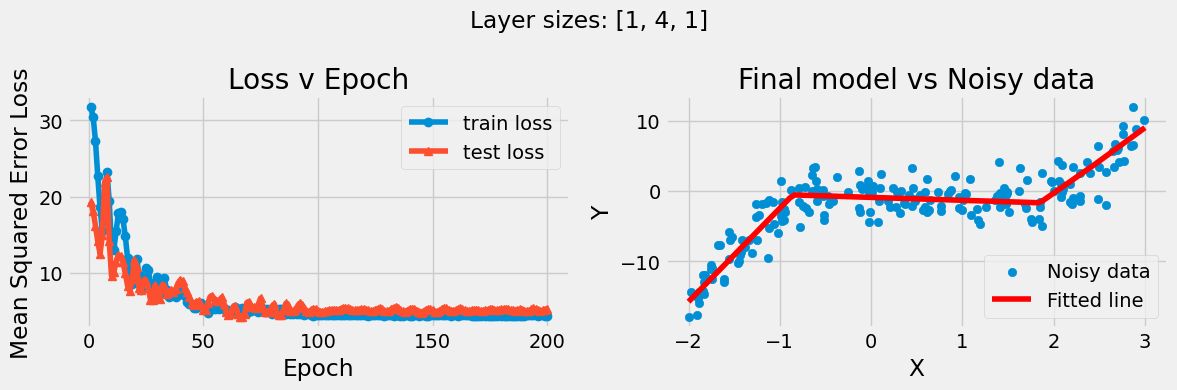

In [12]:
# parameters to change
num_hidden_nodes=4
learning_rate=0.001
epochs=200
batch_size = 32

train_mlp([1,num_hidden_nodes,1],learning_rate,epochs,batch_size)

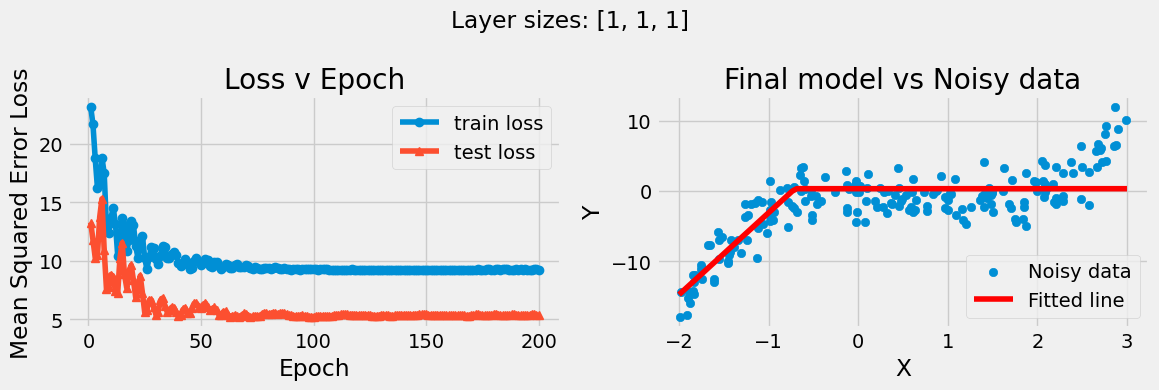

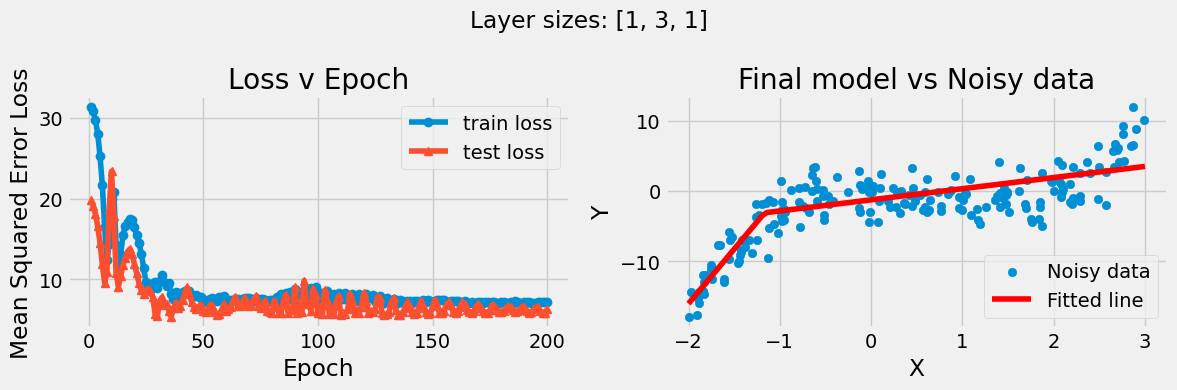

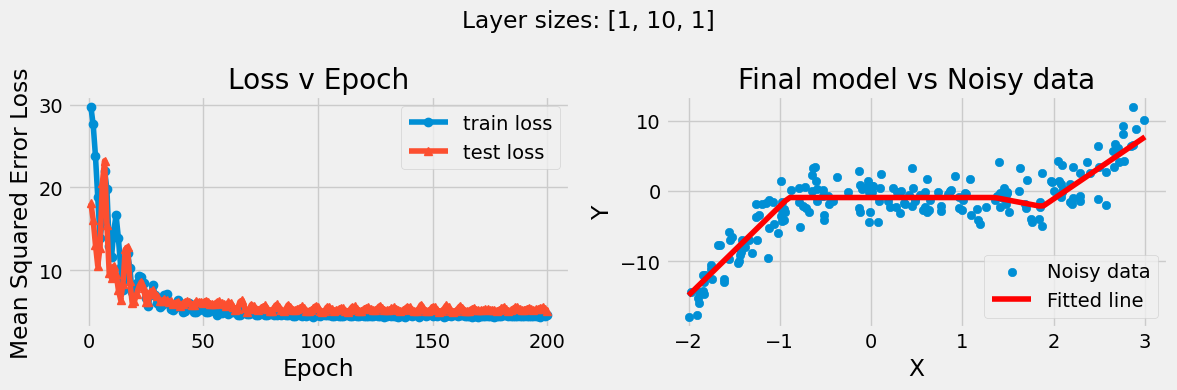

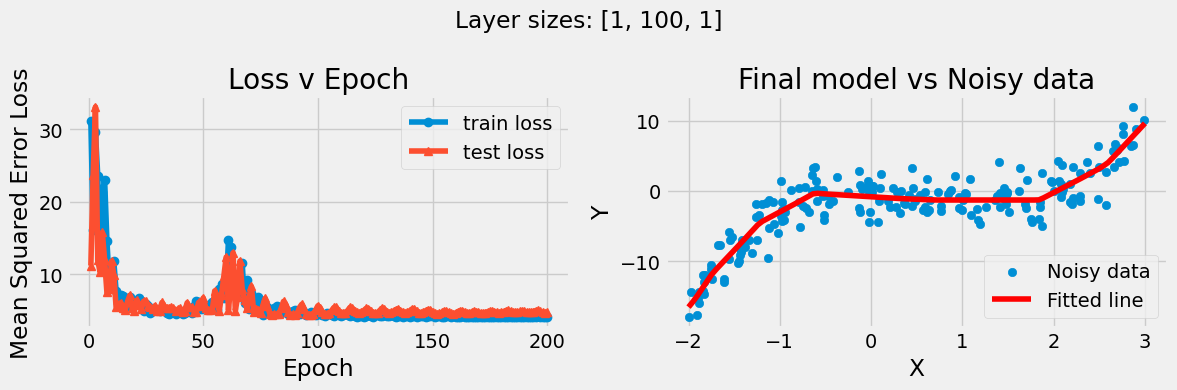

In [13]:
num_nodes = [1,3,10,100]
epochs=200

for num_hidden_nodes in num_nodes:

    train_mlp([1,num_hidden_nodes,1],learning_rate,epochs,batch_size)

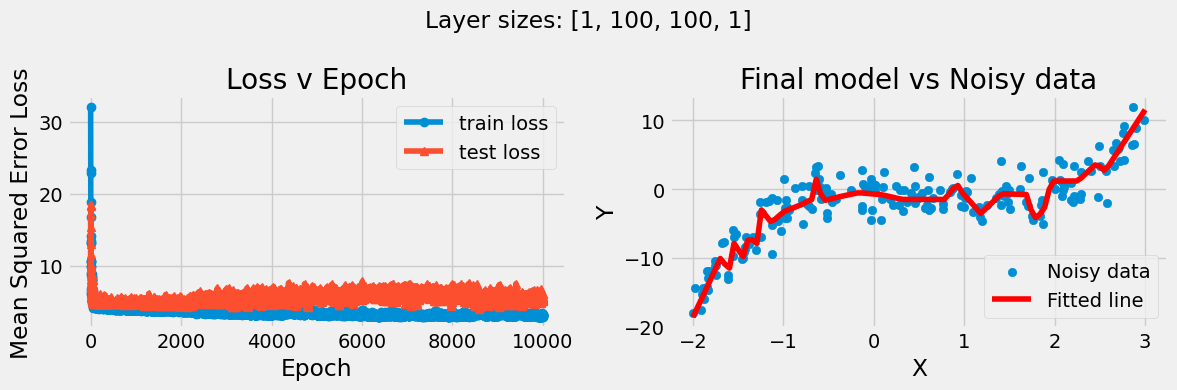

In [14]:
train_mlp([1,100,100,1], 0.001, 10000, batch_size, verbose=False)

## Exercise: Try exploring various hyperparameters 

# A more realistic example: MNIST 

In [16]:
from torchvision import datasets, transforms

# Define the network using nn.Sequential
model = nn.Sequential(
    nn.Flatten(),             # flatten 28x28 images to 784 vector
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
    nn.LogSoftmax(dim=1)
)

# Load MNIST dataset with minimal transformation (just ToTensor)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_size = len(train_dataset)
test_size = len(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

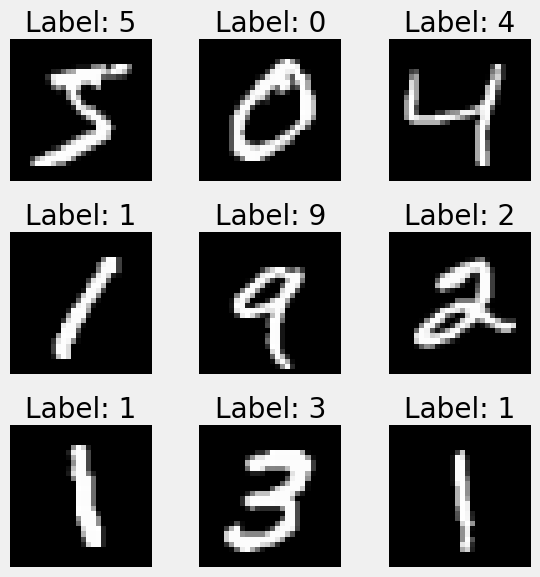

In [17]:
# Plot first 9 images from the training set
fig, axes = plt.subplots(3, 3, figsize=(6,6))
axes = axes.flatten()

for i in range(9):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')  # squeeze to remove channel dimension
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Setup optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# Train the model
trained_model, train_losses, test_losses = train_model(model, optimizer, loss_fn, train_loader, test_loader, train_size, test_size, epochs=5, verbose=True)

Epoch: 1 Train Loss: 0.3402 Test Loss: 0.1694
Epoch: 2 Train Loss: 0.1458 Test Loss: 0.1287
Epoch: 3 Train Loss: 0.0979 Test Loss: 0.0986
Epoch: 4 Train Loss: 0.0741 Test Loss: 0.0933
Epoch: 5 Train Loss: 0.0570 Test Loss: 0.0818


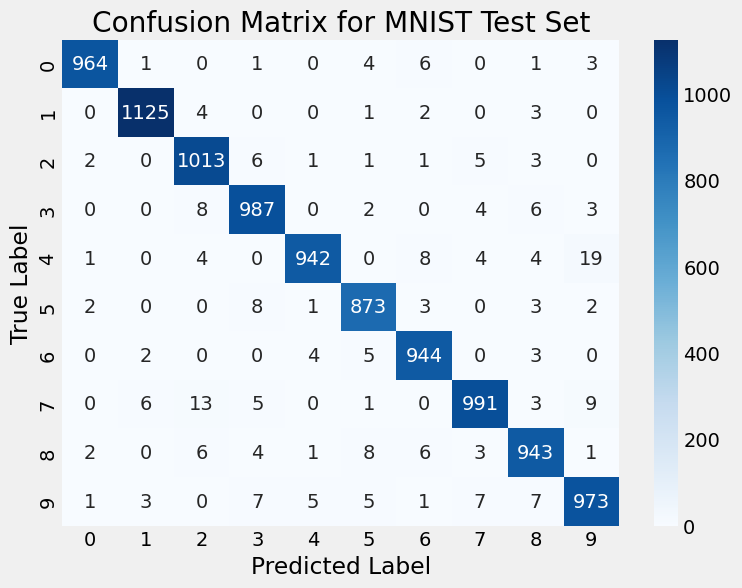

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in DataLoader(test_dataset, batch_size=1000):
        xb, yb = xb.to(device), yb.to(device)
        out = trained_model(xb)
        _, predicted = torch.max(out, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST Test Set')
plt.show()